# Road accidents 2024 — profiling and data quality

We have 4 files linked by `Num_Acc`: `caract` (the accident), `lieux` (the road),
`vehicules` (the vehicles) and `usagers` (the people).

Goal: look at each table to understand the data and spot quality issues
(missing values, weird values, duplicates).

## 1. Load the files

The separator is `;`, the comma is the decimal separator, and `-1` / empty / `N/A` means
"not filled in".

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

def load(name):
    file = glob.glob(name + "*.csv")[0]      # finds the file whatever the year
    return pd.read_csv(file, sep=";", decimal=",",
                       na_values=["-1", " -1", "N/A"], low_memory=False)

caract = load("caract")
lieux = load("lieux")
vehicules = load("vehicules")
usagers = load("usagers")

print("caract   :", caract.shape)
print("lieux    :", lieux.shape)
print("vehicules:", vehicules.shape)
print("usagers  :", usagers.shape)

year = int(caract["an"].mode()[0])
print("Data year:", year)

caract   : (54402, 15)
lieux    : (70248, 18)
vehicules: (92678, 11)
usagers  : (125187, 16)
Data year: 2024


## 2. Preview of the data

In [2]:
caract.head(3)

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202400000001,25,3,2024,07:40,2,70,70285,1,1,5,1.0,D438,47.562770,6.758320
1,202400000002,20,3,2024,15:05,1,21,21054,2,3,7,6.0,HOTEL DIEU (RUE DE L'),47.021090,4.837550
2,202400000003,22,3,2024,19:30,2,15,15012,1,1,1,6.0,Allée des Tilleuls,44.902384,2.496418


In [3]:
usagers.head(3)

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202400000001,203 988 581,155 781 758,A01,1.0,1,3,1.0,2003.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN
1,202400000001,203 988 582,155 781 759,B01,1.0,1,1,1.0,1997.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN
2,202400000002,203 988 579,155 781 757,A01,10.0,3,3,2.0,1927.0,5.0,0.0,NaN,NaN,3.0,3,1.0


## 3. Column types

In [4]:
tables = {"caract": caract, "lieux": lieux, "vehicules": vehicules, "usagers": usagers}

for name, table in tables.items():
    print("---", name, "---")
    print(table.dtypes)
    print()

--- caract ---
Num_Acc      int64
jour         int64
mois         int64
an           int64
hrmn        object
lum          int64
dep         object
com         object
agg          int64
int          int64
atm          int64
col        float64
adr         object
lat        float64
long       float64
dtype: object

--- lieux ---
Num_Acc      int64
catr         int64
voie        object
v1         float64
v2          object
circ       float64
nbv         object
vosp       float64
prof       float64
pr          object
pr1         object
plan       float64
lartpc     float64
larrout    float64
surf       float64
infra      float64
situ       float64
vma        float64
dtype: object

--- vehicules ---
Num_Acc          int64
id_vehicule     object
num_veh         object
senc           float64
catv           float64
obs            float64
obsm           float64
choc           float64
manv           float64
motor          float64
occutc         float64
dtype: object

--- usagers ---
Num_Acc     

We have identifiers (`Num_Acc`, `id_usager`…), codes (`grav`, `sexe`, `lum`… these are
categories, not numbers) and a few real measurements (`lat`, `long`, `an_nais`, `vma`).
The important column is `grav`: the severity (1 unharmed, 2 killed, 3 hospitalized, 4 slightly injured).

## 4. Profile of each column

For each column: its type, how many values are missing, and how many different values it has.

In [5]:
def profile(table):
    summary = pd.DataFrame()
    summary["type"] = table.dtypes
    summary["nb_missing"] = table.isnull().sum()
    summary["pct_missing"] = (table.isnull().mean() * 100).round(1)
    summary["nb_distinct_values"] = table.nunique()
    return summary

profile(caract)

,type,nb_missing,pct_missing,nb_distinct_values
Num_Acc,int64,0,0.0,54402
jour,int64,0,0.0,31
mois,int64,0,0.0,12
an,int64,0,0.0,1
hrmn,object,0,0.0,1414
lum,int64,0,0.0,5
dep,object,0,0.0,107
com,object,0,0.0,11285
agg,int64,0,0.0,2
int,int64,0,0.0,9


In [6]:
profile(lieux)

,type,nb_missing,pct_missing,nb_distinct_values
Num_Acc,int64,0,0.0,54402
catr,int64,0,0.0,8
voie,object,13331,19.0,19750
v1,float64,16272,23.2,3
v2,object,64332,91.6,27
circ,float64,4354,6.2,4
nbv,object,4178,5.9,14
vosp,float64,3832,5.5,4
prof,float64,50,0.1,4
pr,object,27364,39.0,460


In [7]:
profile(vehicules)

,type,nb_missing,pct_missing,nb_distinct_values
Num_Acc,int64,0,0.0,54402
id_vehicule,object,0,0.0,92678
num_veh,object,0,0.0,45
senc,float64,68,0.1,4
catv,float64,1,0.0,31
obs,float64,27,0.0,18
obsm,float64,30,0.0,7
choc,float64,44,0.0,10
manv,float64,27,0.0,27
motor,float64,192,0.2,7


In [8]:
profile(usagers)

,type,nb_missing,pct_missing,nb_distinct_values
Num_Acc,int64,0,0.0,54402
id_usager,object,0,0.0,125187
id_vehicule,object,0,0.0,92654
num_veh,object,0,0.0,45
place,float64,3,0.0,10
catu,int64,0,0.0,3
grav,int64,0,0.0,4
sexe,float64,2395,1.9,2
an_nais,float64,2579,2.1,105
trajet,float64,2626,2.1,7


## 5. Missing values

The percentage of missing values, column by column.

In [9]:
for name, table in tables.items():
    pct = (table.isnull().mean() * 100).round(1)
    pct = pct[pct > 0].sort_values(ascending=False)
    print("---", name, "---")
    if len(pct) == 0:
        print("no missing values")
    else:
        print(pct)
    print()

--- caract ---
adr    4.2
dtype: float64

--- lieux ---
lartpc     100.0
v2          91.6
larrout     69.2
pr1         39.1
pr          39.0
v1          23.2
voie        19.0
circ         6.2
nbv          5.9
vosp         5.5
vma          5.2
infra        1.2
prof         0.1
plan         0.1
surf         0.1
situ         0.1
dtype: float64

--- vehicules ---
occutc    99.0
motor      0.2
senc       0.1
dtype: float64

--- usagers ---
etatp      91.8
secu3      90.4
actp       49.3
locp       49.3
secu2      43.0
trajet      2.1
an_nais     2.1
sexe        1.9
secu1       1.7
dtype: float64



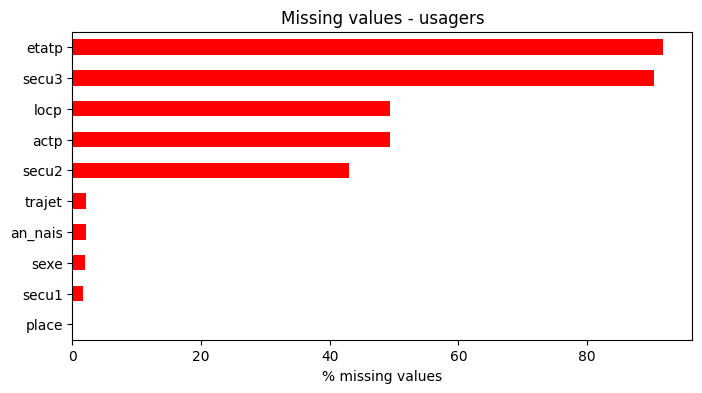

In [10]:
# chart for the usagers table
pct = (usagers.isnull().mean() * 100)
pct = pct[pct > 0].sort_values()
pct.plot(kind="barh", color="red", figsize=(8, 4))
plt.xlabel("% missing values")
plt.title("Missing values - usagers")
plt.show()

**Conclusion per file:**

- **caract**: almost complete, only `adr` (the address) is a bit missing (~4 %).
- **lieux**: many empty columns, but they are road details that are rarely filled in
  (`lartpc` 100 %, `v2` 92 %, `larrout` 69 %, `pr`/`pr1` ~39 %). The only missing value that
  actually matters is `vma` (~5 %).
- **vehicules**: almost complete; `occutc` (99 %) only applies to buses, so that's normal.
- **usagers**: the big gaps are normal (pedestrians or 3rd safety equipment: `etatp` 92 %,
  `secu3` 90 %, `locp`/`actp` ~49 %). The ones that matter a bit: `an_nais`, `sexe`, `secu1`
  (~2 %). `grav` has no missing values at all.

## 6. Values of the coded columns

We look at the values taken by the coded columns, to check there is no weird value.

In [11]:
print("grav:")
print(usagers["grav"].value_counts().sort_index())
print("\nsexe:")
print(usagers["sexe"].value_counts().sort_index())
print("\ncatu (type of user):")
print(usagers["catu"].value_counts().sort_index())
print("\nlum (light conditions):")
print(caract["lum"].value_counts().sort_index())

grav:
grav
1    52920
2     3432
3    19126
4    49709
Name: count, dtype: int64

sexe:
sexe
1.0    83864
2.0    38928
Name: count, dtype: int64

catu (type of user):
catu
1    92581
2    23205
3     9401
Name: count, dtype: int64

lum (light conditions):
lum
1    35580
2     3599
3     6101
4      623
5     8499
Name: count, dtype: int64


The values match what is expected: `grav` goes from 1 to 4, `sexe` is 1 or 2, `catu` from 1
to 3, `lum` from 1 to 5. No unknown category.

## 7. Statistics of the numeric columns

In [12]:
caract[["lat", "long"]].describe()

,lat,long
count,54402.000000,54402.000000
mean,44.051229,1.240096
std,12.665655,19.460609
min,-22.433239,-178.094387
25%,44.519282,1.153567
50%,47.717121,2.392034
75%,48.861732,4.732405
max,51.078740,167.863219


In [13]:
age = year - usagers["an_nais"]
age.describe()

count    122608.000000
mean         38.924589
std          19.327486
min           0.000000
25%          23.000000
50%          36.000000
75%          53.000000
max         110.000000
Name: an_nais, dtype: float64

Ages range from 0 to 110 years old (average ~40), nothing unusual. The coordinates cover
France (mainland + overseas territories, which explains the negative latitudes).

## 8. Are the values valid?

We check the most sensitive columns: coordinates, ages and maximum speed.

### Coordinates
Every point should be in France (mainland or overseas). We list the main French zones and
spot the points that are in none of them.

In [14]:
# (min latitude, max latitude, min longitude, max longitude) for each French zone
france_zones = [
    (41.3, 51.1, -5.3, 9.6),      # mainland
    (14.3, 16.6, -61.9, -60.8),   # Antilles
    (2.0, 5.8, -54.7, -51.5),     # Guyana
    (-21.4, -12.4, 45.0, 55.9),   # Reunion + Mayotte
    (46.7, 47.2, -56.5, -56.1),   # Saint-Pierre-et-Miquelon
    (17.8, 18.2, -63.2, -62.7),   # Saint-Martin
    (-28, -7, -155, -134),        # Polynesia
    (-22.9, -19.5, 163.5, 168.2), # New Caledonia
    (-14.4, -13.1, -178.3, -176), # Wallis and Futuna
]

def in_france(lat, lon):
    for lat_min, lat_max, lon_min, lon_max in france_zones:
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return True
    return False

caract["coord_ok"] = caract.apply(lambda row: in_france(row["lat"], row["long"]), axis=1)
bad_rows = caract[caract["coord_ok"] == False]
print("Coordinates outside France:", len(bad_rows))
bad_rows[["Num_Acc", "dep", "lat", "long"]]

Coordinates outside France: 9


,Num_Acc,dep,lat,long
2079,202400002080,976,45.16376,-12.78954
5347,202400005348,976,45.23097,12.75862
8234,202400008235,2B,9.44460,42.67720
11272,202400011273,2B,9.44085,42.65160
13465,202400013466,2B,9.44430,42.67720
18638,202400018639,976,45.23233,-12.78381
21732,202400021733,976,45.23507,12.78223
24443,202400024444,976,45.22950,-12.78421
49893,202400049894,976,45.22602,-12.76237


These 9 rows have **latitude and longitude swapped**: Mayotte (dep 976) should be around
`lat -12, long 45` but we find `lat 45, long -12`, and the same for Haute-Corse (2B). Result: the
point lands in the middle of the sea. To fix (swap them back).

### Ages

In [15]:
age = year - usagers["an_nais"]
print("Minimum age:", age.min())
print("Maximum age:", age.max())
print("Negative ages:", (age < 0).sum())
print("Ages above 110:", (age > 110).sum())

Minimum age: 0.0
Maximum age: 110.0
Negative ages: 0
Ages above 110: 0


### Maximum speed (vma)
In France the maximum legal speed never goes above 130 km/h.

In [16]:
weird_vma = lieux[lieux["vma"] > 130]
print("Impossible max speeds (> 130 km/h):", len(weird_vma))
print("Values found:", sorted(weird_vma["vma"].dropna().unique()))

Impossible max speeds (> 130 km/h): 29
Values found: [np.float64(140.0), np.float64(300.0), np.float64(301.0), np.float64(500.0), np.float64(700.0), np.float64(800.0), np.float64(900.0)]


Ages are correct (0 to 110, no negative values). On the other hand `vma` has impossible
values, up to **900 km/h**: these are data entry errors that need to be cleaned.

## 9. Duplicates and keys

We check for duplicate rows and whether each table has a unique identifier.

In [17]:
for name, table in tables.items():
    print(name, ":", table.duplicated().sum(), "duplicate(s)")

caract : 0 duplicate(s)
lieux : 2 duplicate(s)


vehicules : 0 duplicate(s)


usagers : 0 duplicate(s)


In [18]:
# a primary key must be unique
print("caract    - Num_Acc unique?    ", caract["Num_Acc"].is_unique)
print("vehicules - id_vehicule unique?", vehicules["id_vehicule"].is_unique)
print("usagers   - id_usager unique?  ", usagers["id_usager"].is_unique)
print("lieux     - Num_Acc unique?    ", lieux["Num_Acc"].is_unique)
print()
print("lieux: ", len(lieux), "rows for", lieux["Num_Acc"].nunique(), "accidents")

caract    - Num_Acc unique?     True
vehicules - id_vehicule unique? True
usagers   - id_usager unique?   True
lieux     - Num_Acc unique?     False

lieux:  70248 rows for 54402 accidents


In [19]:
# does every Num_Acc in the other tables exist in caract?
accidents = caract["Num_Acc"]
for name in ["lieux", "vehicules", "usagers"]:
    missing = (~tables[name]["Num_Acc"].isin(accidents)).sum()
    print(name, ": rows with no matching accident ->", missing)

lieux : rows with no matching accident -> 0
vehicules : rows with no matching accident -> 0
usagers : rows with no matching accident -> 0


- Only 2 duplicates in `lieux`, 0 elsewhere.
- `caract`, `vehicules` and `usagers` each have a unique identifier (primary key).
- **`lieux` has no unique key**: it has more rows than accidents (several roads per accident at
  intersections). We need to be careful not to count an accident twice when joining tables.
- All tables link properly to `caract` (no orphan rows).

## 10. Dates

We check that the dates are consistent.

In [20]:
print("Years :", sorted(caract["an"].dropna().unique()))
print("Months:", sorted(caract["mois"].dropna().unique()))
print("Days  : from", int(caract["jour"].min()), "to", int(caract["jour"].max()))

Years : [np.int64(2024)]
Months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Days  : from 1 to 31


Everything is on a single year, with months from 1 to 12 and days from 1 to 31. Nothing unusual.

## 11. Summary

What we take away:

- `grav` (the severity) has no missing values: perfect, that's the column we want to analyze.
- A few missing values to keep an eye on: `an_nais`, `sexe`, `vma`. The very empty columns
  (pedestrian, `secu3`) are not a real problem.
- The codes (grav, sexe, lum…) are all correct, and so are the ages.
- Two real issues to fix: **9 swapped coordinates** (landing in the sea) and **`vma` with
  impossible values** (up to 900 km/h).
- `lieux` has no unique key (several rows per accident) → watch out for double counting.

Overall the data is fairly good quality. The main things to fix are the coordinates, cleaning up
`vma`, giving `lieux` a proper key, and replacing `-1` with "unknown".